# Explainability & Forecast Error Analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import joblib

from sklearn.inspection import (
    permutation_importance
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score
)

import statsmodels.api as sm

from statsmodels.graphics.tsaplots import (
    plot_acf
)

from statsmodels.stats.diagnostic import (
    acorr_ljungbox
)

pd.set_option(
    'display.max_columns',
    None
)

pd.set_option(
    'display.max_rows',
    200
)

sns.set_theme(
    style="whitegrid"
)

In [2]:
PROJECT_ROOT = Path("..")

ML_DIR = (
    PROJECT_ROOT /
    "data" /
    "processed" /
    "ml"
)

REPORTS_DIR = (
    PROJECT_ROOT /
    "reports"
)

PHASE8_TABLES = (
    REPORTS_DIR /
    "tables" /
    "phase8_ml_preparation"
)

PHASE9_TABLES = (
    REPORTS_DIR /
    "tables" /
    "phase9_models"
)

TABLES_DIR = (
    REPORTS_DIR /
    "tables" /
    "phase10_explainability"
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODELS_DIR = (
    PROJECT_ROOT /
    "models" /
    "phase9"
)

In [3]:
#Ridge model
final_model = joblib.load(
    MODELS_DIR /
    "ridge_24h.joblib"
)

final_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](55,)","['pm25','pm10','no2',...,'target_dow_cos','target_doy_sin', 'target_doy_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,55
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [4]:
train_df = pd.read_csv(
    ML_DIR / "train.csv",
    parse_dates=[
        'time',
        'target_time'
    ],
    index_col='time'
)

validation_df = pd.read_csv(
    ML_DIR / "validation.csv",
    parse_dates=[
        'time',
        'target_time'
    ],
    index_col='time'
)

test_df = pd.read_csv(
    ML_DIR / "test.csv",
    parse_dates=[
        'time',
        'target_time'
    ],
    index_col='time'
)

In [5]:
feature_table = pd.read_csv(
    PHASE8_TABLES /
    "forecast_feature_list.csv"
)

feature_columns = (
    feature_table[
        'feature'
    ]
    .tolist()
)

In [6]:
#test data
TARGET = 'target_pm25_24h'

X_test = (
    test_df[
        feature_columns
    ].copy()
)

y_test = (
    test_df[
        TARGET
    ].copy()
)

In [7]:
ridge_pred = (
    final_model.predict(
        X_test
    )
)

persistence_pred = (
    test_df[
        'baseline_persistence'
    ].to_numpy()
)

In [8]:
def metrics(
    y_true,
    y_pred
):

    return {
        'MAE':
            mean_absolute_error(
                y_true,
                y_pred
            ),

        'RMSE':
            np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred
                )
            ),

        'R2':
            r2_score(
                y_true,
                y_pred
            )
    }

In [9]:
ridge_metrics = metrics(
    y_test,
    ridge_pred
)

persistence_metrics = metrics(
    y_test,
    persistence_pred
)

print(
    "Ridge:",
    ridge_metrics
)

print(
    "Persistence:",
    persistence_metrics
)

Ridge: {'MAE': 11.314113712667423, 'RMSE': np.float64(15.02766725897061), 'R2': 0.776518125518711}
Persistence: {'MAE': 12.085159420289855, 'RMSE': np.float64(16.284394948556724), 'R2': 0.7375766843812281}


## Ridge coefficient explainability

In [10]:
#Extract Ridge coefficients
scaler = (
    final_model
    .named_steps[
        'scaler'
    ]
)

ridge = (
    final_model
    .named_steps[
        'ridge'
    ]
)

In [11]:
ridge_coefficients = pd.DataFrame({
    'feature':
        feature_columns,

    'coefficient':
        ridge.coef_
})

In [12]:
ridge_coefficients[
    'abs_coefficient'
] = (
    ridge_coefficients[
        'coefficient'
    ]
    .abs()
)

In [13]:
ridge_coefficients = (
    ridge_coefficients
    .sort_values(
        'abs_coefficient',
        ascending=False
    )
)

ridge_coefficients.head(20)

,feature,coefficient,abs_coefficient
0,pm25,3.954037,3.954037
35,pm10_lag_24,3.945268,3.945268
13,pm25_lag_1,3.856402,3.856402
27,pm25_roll_mean_72,-2.861701,2.861701
28,pm25_roll_std_72,2.629514,2.629514
3,so2,2.570993,2.570993
33,pm25_change_24h,2.559694,2.559694
17,pm25_lag_24,2.495987,2.495987
34,pm10_lag_1,-2.368310,2.368310
1,pm10,-2.366137,2.366137


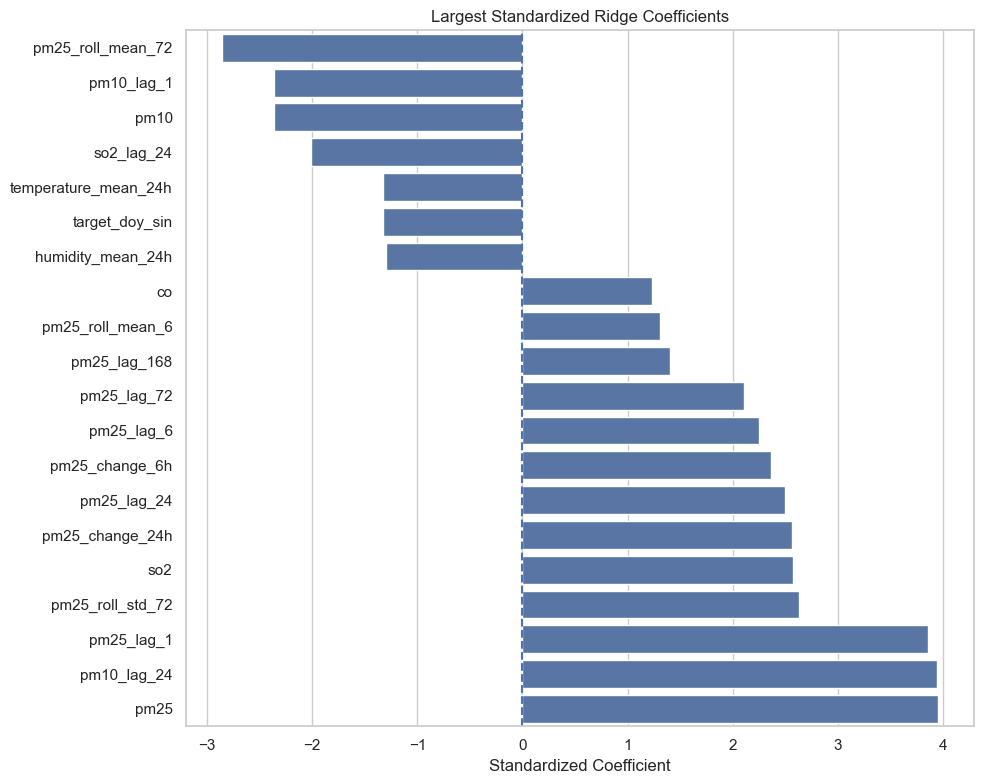

In [14]:
#top coefficients
top_coef = (
    ridge_coefficients
    .head(20)
    .sort_values(
        'coefficient'
    )
)

plt.figure(
    figsize=(10, 8)
)

sns.barplot(
    data=top_coef,
    x='coefficient',
    y='feature',
    orient='h'
)

plt.axvline(
    0,
    linestyle='--'
)

plt.title(
    'Largest Standardized Ridge Coefficients'
)

plt.xlabel(
    'Standardized Coefficient'
)

plt.ylabel('')

plt.tight_layout()
plt.show()

## Group feature importance

In [15]:
#Feature-group function
def get_feature_group(
    feature
):

    if feature == 'pm25':
        return 'Current PM2.5'

    if feature.startswith(
        'pm25_lag_'
    ):
        return 'PM2.5 Lags'

    if feature.startswith(
        'pm25_roll_'
    ):
        return 'PM2.5 Rolling'

    if feature.startswith(
        'pm25_change_'
    ):
        return 'PM2.5 Change'

    if (
        feature.startswith(
            'pm10'
        )
        or feature.startswith(
            'no2'
        )
        or feature.startswith(
            'so2'
        )
        or feature.startswith(
            'co'
        )
    ):
        return 'Co-Pollutants'

    if feature.startswith(
        'target_'
    ):
        return 'Target Calendar'

    if (
        'temperature' in feature
        or 'humidity' in feature
        or 'rain' in feature
        or 'wind' in feature
        or 'pressure' in feature
        or 'dew_point' in feature
    ):
        return 'Meteorology'

    return 'Other'

In [16]:
ridge_coefficients[
    'group'
] = (
    ridge_coefficients[
        'feature'
    ]
    .apply(
        get_feature_group
    )
)

In [17]:
coefficient_groups = (
    ridge_coefficients
    .groupby('group')[
        'abs_coefficient'
    ]
    .sum()
    .sort_values(
        ascending=False
    )
)

coefficient_groups

group
Co-Pollutants      19.589217
PM2.5 Lags         12.845666
PM2.5 Rolling      10.765105
Meteorology         9.627745
PM2.5 Change        5.324961
Current PM2.5       3.954037
Target Calendar     2.948684
Name: abs_coefficient, dtype: float64

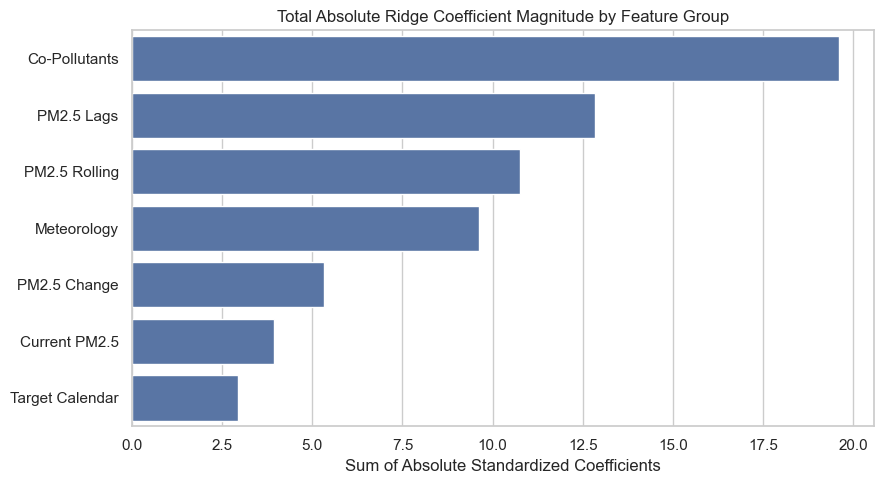

In [18]:
plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    x=coefficient_groups.values,
    y=coefficient_groups.index
)

plt.title(
    'Total Absolute Ridge Coefficient Magnitude by Feature Group'
)

plt.xlabel(
    'Sum of Absolute Standardized Coefficients'
)

plt.ylabel('')

plt.tight_layout()
plt.show()

## Permutation importance

In [19]:
#Compute permutation importance
perm = permutation_importance(
    final_model,
    X_test,
    y_test,

    scoring=
        'neg_mean_absolute_error',

    n_repeats=10,

    random_state=42,

    n_jobs=-1
)

In [20]:
permutation_table = pd.DataFrame({
    'feature':
        feature_columns,

    'importance_mean':
        perm.importances_mean,

    'importance_std':
        perm.importances_std
})

In [21]:
permutation_table = (
    permutation_table
    .sort_values(
        'importance_mean',
        ascending=False
    )
)

permutation_table.head(20)

,feature,importance_mean,importance_std
32,pm25_change_6h,2.758270,0.092672
0,pm25,2.655603,0.074396
13,pm25_lag_1,2.465735,0.065268
3,so2,1.831865,0.078453
35,pm10_lag_24,1.685526,0.051782
17,pm25_lag_24,1.219066,0.039831
27,pm25_roll_mean_72,0.904602,0.045105
39,so2_lag_24,0.851338,0.068118
28,pm25_roll_std_72,0.809854,0.066120
33,pm25_change_24h,0.784908,0.051992


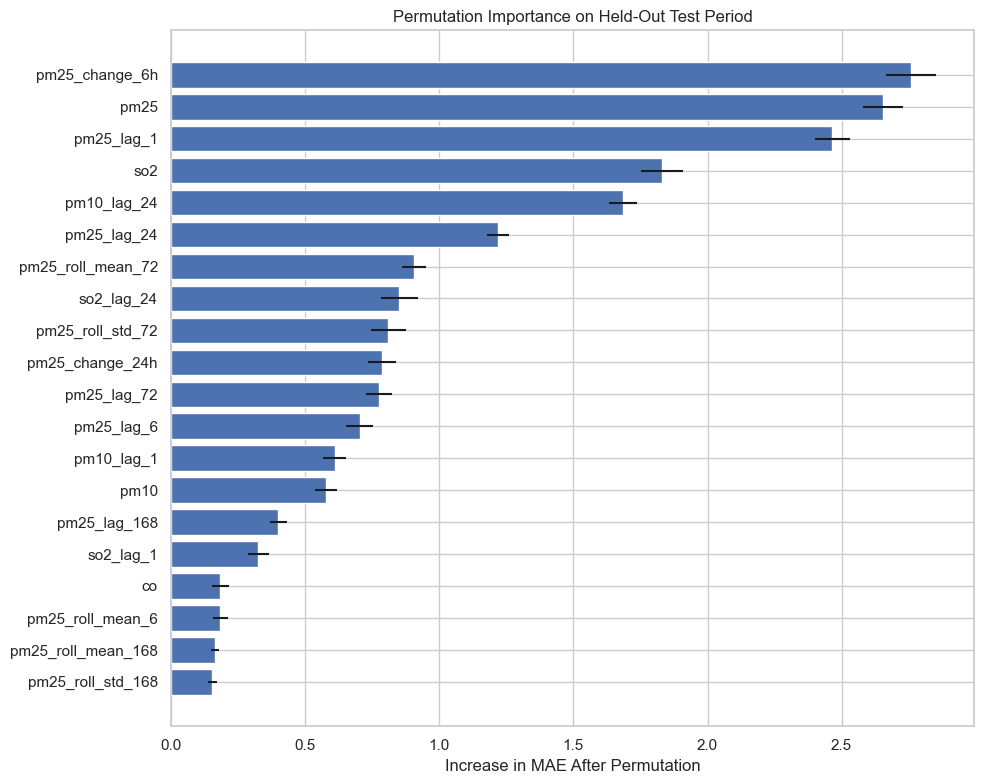

In [22]:
#top permutation features
top_perm = (
    permutation_table
    .head(20)
    .sort_values(
        'importance_mean'
    )
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top_perm[
        'feature'
    ],

    top_perm[
        'importance_mean'
    ],

    xerr=
        top_perm[
            'importance_std'
        ]
)

plt.title(
    'Permutation Importance on Held-Out Test Period'
)

plt.xlabel(
    'Increase in MAE After Permutation'
)

plt.tight_layout()
plt.show()

Permutation importance should be interpreted cautiously because many lagged and rolling PM2.5 predictors are strongly correlated. When correlated predictors contain overlapping information, shuffling one feature may underestimate its total importance because related features remain available to the model.

## Build detailed error dataframe

In [23]:
error_df = pd.DataFrame(
    index=test_df.index
)

error_df[
    'target_time'
] = (
    test_df[
        'target_time'
    ]
)

error_df[
    'actual'
] = y_test

error_df[
    'ridge'
] = ridge_pred

error_df[
    'persistence'
] = persistence_pred

In [24]:
error_df[
    'ridge_error'
] = (
    error_df['ridge']
    - error_df['actual']
)

error_df[
    'persistence_error'
] = (
    error_df['persistence']
    - error_df['actual']
)

In [25]:
#absolute errors
error_df[
    'ridge_abs_error'
] = (
    error_df[
        'ridge_error'
    ]
    .abs()
)

error_df[
    'persistence_abs_error'
] = (
    error_df[
        'persistence_error'
    ]
    .abs()
)

In [26]:
#squared
error_df[
    'ridge_sq_error'
] = (
    error_df[
        'ridge_error'
    ] ** 2
)

error_df[
    'persistence_sq_error'
] = (
    error_df[
        'persistence_error'
    ] ** 2
)

## Bias

In [27]:
#overall forecast bias
bias_summary = pd.DataFrame({
    'Ridge': {
        'Mean Error':
            error_df[
                'ridge_error'
            ].mean(),

        'Median Error':
            error_df[
                'ridge_error'
            ].median(),

        'Underprediction Rate':
            (
                error_df[
                    'ridge_error'
                ] < 0
            ).mean(),

        'Overprediction Rate':
            (
                error_df[
                    'ridge_error'
                ] > 0
            ).mean()
    },

    'Persistence': {
        'Mean Error':
            error_df[
                'persistence_error'
            ].mean(),

        'Median Error':
            error_df[
                'persistence_error'
            ].median(),

        'Underprediction Rate':
            (
                error_df[
                    'persistence_error'
                ] < 0
            ).mean(),

        'Overprediction Rate':
            (
                error_df[
                    'persistence_error'
                ] > 0
            ).mean()
    }
})

bias_summary.round(3)

,Ridge,Persistence
Mean Error,-0.634,0.300
Median Error,0.220,-0.500
Underprediction Rate,0.491,0.516
Overprediction Rate,0.509,0.480


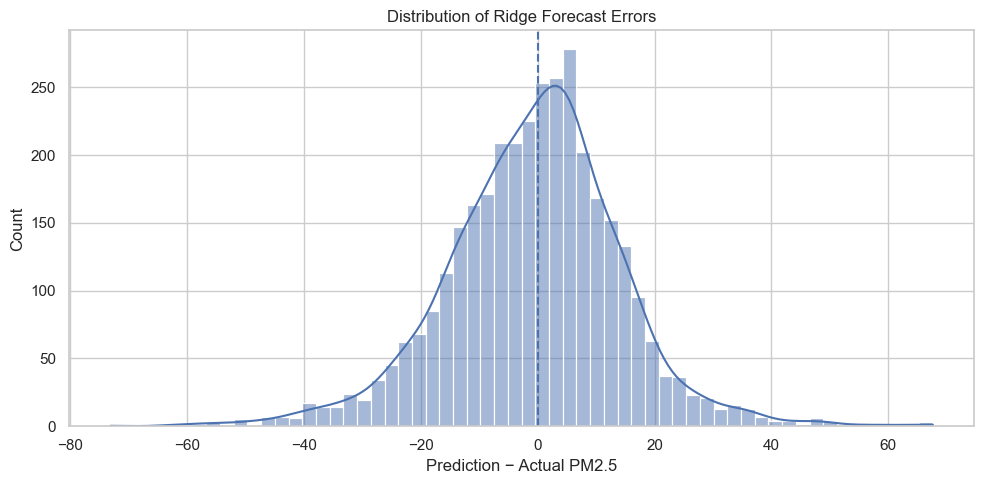

In [28]:
#error distribution
plt.figure(
    figsize=(10, 5)
)

sns.histplot(
    error_df[
        'ridge_error'
    ],
    bins=60,
    kde=True
)

plt.axvline(
    0,
    linestyle='--'
)

plt.title(
    'Distribution of Ridge Forecast Errors'
)

plt.xlabel(
    'Prediction − Actual PM2.5'
)

plt.tight_layout()
plt.show()

In [29]:
#Observation-level improvement
error_df[
    'ridge_improvement'
] = (
    error_df[
        'persistence_abs_error'
    ]
    -
    error_df[
        'ridge_abs_error'
    ]
)

In [30]:
ridge_win_rate = (
    error_df[
        'ridge_improvement'
    ] > 0
).mean()

persistence_win_rate = (
    error_df[
        'ridge_improvement'
    ] < 0
).mean()

tie_rate = (
    error_df[
        'ridge_improvement'
    ] == 0
).mean()

print(
    "Ridge win rate:",
    ridge_win_rate
)

print(
    "Persistence win rate:",
    persistence_win_rate
)

print(
    "Tie rate:",
    tie_rate
)

print(
    "Median Ridge improvement:",
    error_df[
        'ridge_improvement'
    ].median()
)

Ridge win rate: 0.553623188405797
Persistence win rate: 0.4463768115942029
Tie rate: 0.0
Median Ridge improvement: 0.6714149110791325


## Is Ridge's improvement statistically meaningful?

In [31]:
#Absolute-error loss differential
mae_loss_difference = (
    error_df[
        'persistence_abs_error'
    ]
    -
    error_df[
        'ridge_abs_error'
    ]
)

In [32]:
X_intercept = np.ones(
    len(
        mae_loss_difference
    )
)

mae_loss_test = (
    sm.OLS(
        mae_loss_difference.values,
        X_intercept
    )
    .fit(
        cov_type='HAC',
        cov_kwds={
            'maxlags': 24
        }
    )
)

In [33]:
mae_difference_test = pd.Series({
    'mean_loss_improvement':
        mae_loss_test.params[0],

    'hac_standard_error':
        mae_loss_test.bse[0],

    't_statistic':
        mae_loss_test.tvalues[0],

    'p_value':
        mae_loss_test.pvalues[0],

    'ci_lower':
        mae_loss_test.conf_int()[
            0,
            0
        ],

    'ci_upper':
        mae_loss_test.conf_int()[
            0,
            1
        ]
})

mae_difference_test

mean_loss_improvement    0.771046
hac_standard_error       0.316421
t_statistic              2.436775
p_value                  0.014819
ci_lower                 0.150873
ci_upper                 1.391219
dtype: float64

Positive and statistically supported mean loss difference means Ridge achieved lower absolute forecast error than persistence on average during the test period.

In [34]:
#Squared-error comparison
mse_loss_difference = (
    error_df[
        'persistence_sq_error'
    ]
    -
    error_df[
        'ridge_sq_error'
    ]
)

In [35]:
mse_loss_test = (
    sm.OLS(
        mse_loss_difference.values,
        np.ones(
            len(
                mse_loss_difference
            )
        )
    )
    .fit(
        cov_type='HAC',
        cov_kwds={
            'maxlags': 24
        }
    )
)

In [36]:
mse_difference_test = pd.Series({
    'mean_loss_improvement':
        mse_loss_test.params[0],

    'p_value':
        mse_loss_test.pvalues[0],

    'ci_lower':
        mse_loss_test.conf_int()[
            0,
            0
        ],

    'ci_upper':
        mse_loss_test.conf_int()[
            0,
            1
        ]
})

mse_difference_test

mean_loss_improvement    39.350736
p_value                   0.003453
ci_lower                 12.976137
ci_upper                 65.725334
dtype: float64

## Error by target season

In [37]:
#season function
def get_season(
    month
):

    if month in [
        12,
        1,
        2
    ]:
        return 'Winter'

    elif month in [
        3,
        4,
        5
    ]:
        return 'Pre-Monsoon'

    elif month in [
        6,
        7,
        8,
        9
    ]:
        return 'Monsoon'

    else:
        return 'Post-Monsoon'

In [38]:
error_df[
    'target_month'
] = (
    error_df[
        'target_time'
    ]
    .dt.month
)

error_df[
    'target_hour'
] = (
    error_df[
        'target_time'
    ]
    .dt.hour
)

error_df[
    'target_season'
] = (
    error_df[
        'target_month'
    ]
    .apply(
        get_season
    )
)

In [39]:
#Metrics helper by subgroup
def subgroup_metrics(
    group
):

    return pd.Series({
        'n':
            len(group),

        'Ridge_MAE':
            group[
                'ridge_abs_error'
            ].mean(),

        'Persistence_MAE':
            group[
                'persistence_abs_error'
            ].mean(),

        'Ridge_RMSE':
            np.sqrt(
                group[
                    'ridge_sq_error'
                ].mean()
            ),

        'Persistence_RMSE':
            np.sqrt(
                group[
                    'persistence_sq_error'
                ].mean()
            ),

        'Ridge_Bias':
            group[
                'ridge_error'
            ].mean()
    })

In [40]:
#season
season_error = (
    error_df
    .groupby(
        'target_season'
    )
    .apply(
        subgroup_metrics
    )
)

season_error[
    'MAE_Skill'
] = (
    1
    -
    season_error[
        'Ridge_MAE'
    ]
    /
    season_error[
        'Persistence_MAE'
    ]
)

season_error.round(3)

,n,Ridge_MAE,Persistence_MAE,Ridge_RMSE,Persistence_RMSE,Ridge_Bias,MAE_Skill
target_season,,,,,,,
Pre-Monsoon,1464.0,11.876,11.956,15.324,15.912,-0.693,0.007
Winter,1986.0,10.900,12.180,14.805,16.554,-0.591,0.105


## Error by target month

In [41]:
month_error = (
    error_df
    .groupby(
        'target_month'
    )
    .apply(
        subgroup_metrics
    )
)

month_error[
    'MAE_Skill'
] = (
    1
    -
    month_error[
        'Ridge_MAE'
    ]
    /
    month_error[
        'Persistence_MAE'
    ]
)

month_error.round(3)

,n,Ridge_MAE,Persistence_MAE,Ridge_RMSE,Persistence_RMSE,Ridge_Bias,MAE_Skill
target_month,,,,,,,
1,744.0,10.025,10.555,13.599,14.341,-1.516,0.050
2,672.0,11.780,14.232,16.037,18.847,-0.601,0.172
3,744.0,13.342,12.478,17.433,17.290,-0.626,-0.069
4,720.0,10.362,11.417,12.785,14.349,-0.763,0.092
12,570.0,11.003,11.883,14.804,16.356,0.628,0.074


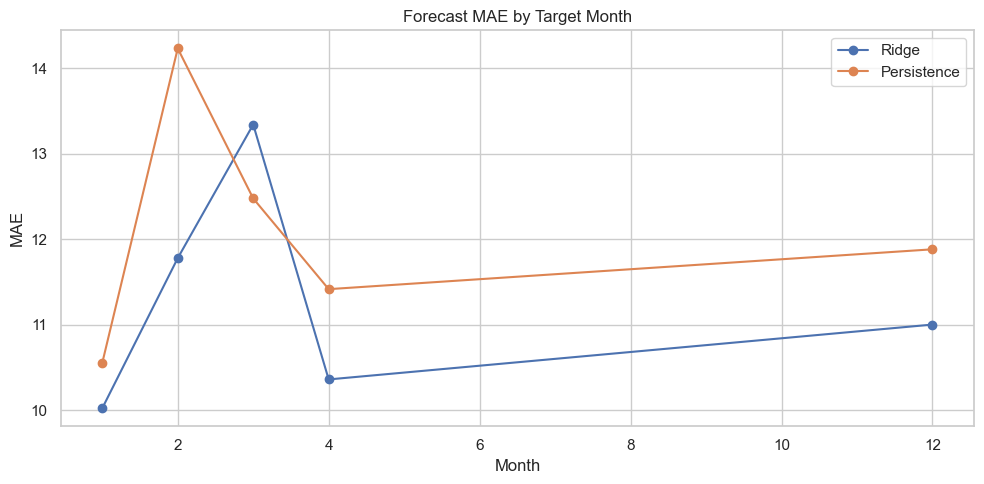

In [42]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    month_error.index,
    month_error[
        'Ridge_MAE'
    ],
    marker='o',
    label='Ridge'
)

plt.plot(
    month_error.index,
    month_error[
        'Persistence_MAE'
    ],
    marker='o',
    label='Persistence'
)

plt.title(
    'Forecast MAE by Target Month'
)

plt.xlabel('Month')
plt.ylabel('MAE')

plt.legend()

plt.tight_layout()
plt.show()

## Error by target hour

In [43]:
hour_error = (
    error_df
    .groupby(
        'target_hour'
    )
    .apply(
        subgroup_metrics
    )
)

hour_error[
    'MAE_Skill'
] = (
    1
    -
    hour_error[
        'Ridge_MAE'
    ]
    /
    hour_error[
        'Persistence_MAE'
    ]
)

hour_error.round(3)

,n,Ridge_MAE,Persistence_MAE,Ridge_RMSE,Persistence_RMSE,Ridge_Bias,MAE_Skill
target_hour,,,,,,,
0,143.0,13.390,14.185,17.094,18.219,-2.109,0.056
1,143.0,12.748,13.681,16.429,17.638,-1.765,0.068
2,143.0,12.139,13.040,15.984,17.195,-1.295,0.069
3,143.0,12.079,13.225,16.185,17.615,-1.273,0.087
4,143.0,12.240,13.478,16.386,18.010,-1.411,0.092
5,143.0,12.387,13.636,16.933,18.660,-0.908,0.092
6,144.0,13.182,14.430,18.005,19.841,-0.903,0.086
7,144.0,14.213,15.462,19.346,21.239,-1.354,0.081
8,144.0,14.019,15.113,18.761,20.208,-0.236,0.072


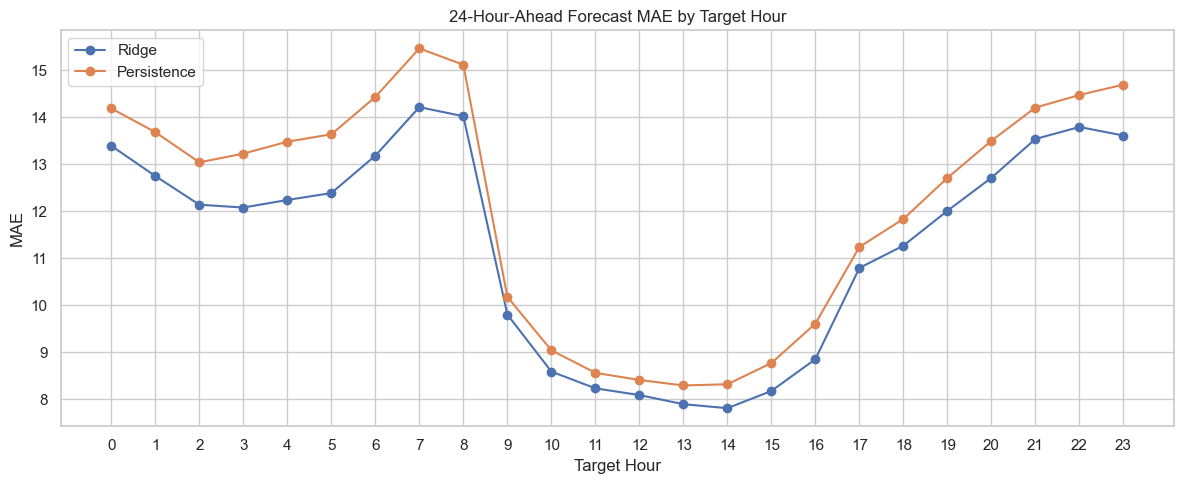

In [44]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    hour_error.index,
    hour_error[
        'Ridge_MAE'
    ],
    marker='o',
    label='Ridge'
)

plt.plot(
    hour_error.index,
    hour_error[
        'Persistence_MAE'
    ],
    marker='o',
    label='Persistence'
)

plt.xticks(
    range(24)
)

plt.title(
    '24-Hour-Ahead Forecast MAE by Target Hour'
)

plt.xlabel(
    'Target Hour'
)

plt.ylabel('MAE')

plt.legend()

plt.tight_layout()
plt.show()

## Performance by pollution severity

In [45]:
#Development-set thresholds
development_df = pd.concat(
    [
        train_df,
        validation_df
    ]
).sort_index()

development_target = (
    development_df[
        TARGET
    ]
)

In [46]:
severity_thresholds = {
    'q50':
        development_target
        .quantile(0.50),

    'q75':
        development_target
        .quantile(0.75),

    'q90':
        development_target
        .quantile(0.90),

    'q95':
        development_target
        .quantile(0.95)
}

severity_thresholds

{'q50': np.float64(26.7),
 'q75': np.float64(40.3),
 'q90': np.float64(55.5),
 'q95': np.float64(66.1)}

In [47]:
#pollution regimes
q50 = severity_thresholds['q50']
q75 = severity_thresholds['q75']
q90 = severity_thresholds['q90']
q95 = severity_thresholds['q95']

In [48]:
severity_bins = [
    -np.inf,
    q50,
    q75,
    q90,
    q95,
    np.inf
]

severity_labels = [
    'Low / Typical',
    'Elevated',
    'High',
    'Very High',
    'Extreme'
]

In [49]:
error_df[
    'pollution_regime'
] = pd.cut(
    error_df[
        'actual'
    ],
    bins=
        severity_bins,
    labels=
        severity_labels,
    include_lowest=True
)

In [50]:
#Metrics by pollution regime
regime_error = (
    error_df
    .groupby(
        'pollution_regime',
        observed=False
    )
    .apply(
        subgroup_metrics
    )
)

regime_error[
    'MAE_Skill'
] = (
    1
    -
    regime_error[
        'Ridge_MAE'
    ]
    /
    regime_error[
        'Persistence_MAE'
    ]
)

regime_error.round(3)

,n,Ridge_MAE,Persistence_MAE,Ridge_RMSE,Persistence_RMSE,Ridge_Bias,MAE_Skill
pollution_regime,,,,,,,
Low / Typical,575.0,8.768,7.809,11.181,11.110,7.979,-0.123
Elevated,676.0,9.012,9.639,12.057,12.971,3.506,0.065
High,576.0,10.787,12.589,14.691,17.427,0.502,0.143
Very High,279.0,12.838,13.807,15.601,17.304,-2.408,0.070
Extreme,1344.0,13.471,14.572,17.609,18.734,-6.521,0.076


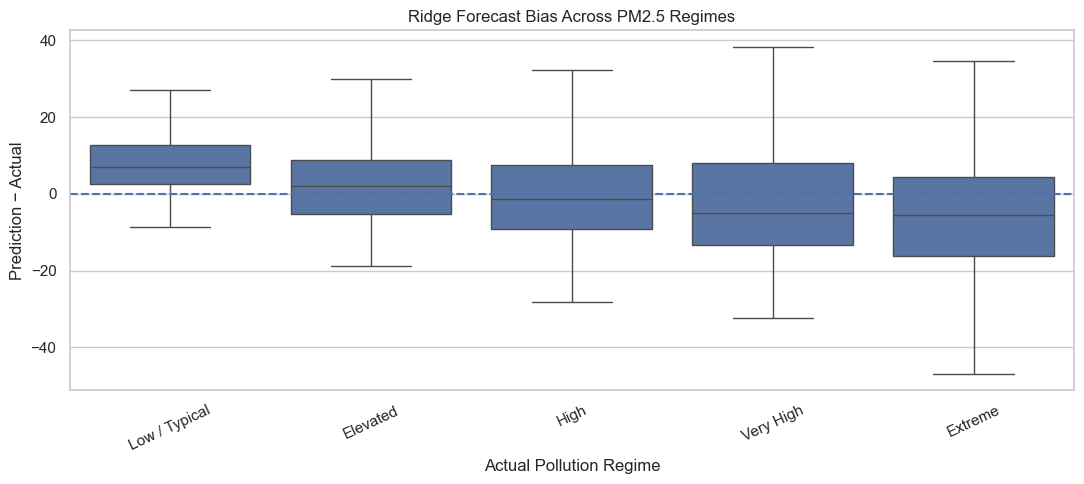

In [51]:
#Bias by pollution level
plt.figure(
    figsize=(11, 5)
)

sns.boxplot(
    data=error_df,
    x='pollution_regime',
    y='ridge_error',
    showfliers=False
)

plt.axhline(
    0,
    linestyle='--'
)

plt.xticks(
    rotation=25
)

plt.title(
    'Ridge Forecast Bias Across PM2.5 Regimes'
)

plt.xlabel('Actual Pollution Regime')

plt.ylabel(
    'Prediction − Actual'
)

plt.tight_layout()
plt.show()

## Extreme-event detection performance

In [52]:
# extreme threshold
extreme_threshold = q90

print(
    "Development-derived "
    "90th percentile:",
    extreme_threshold
)

Development-derived 90th percentile: 55.5


In [53]:
actual_extreme = (
    error_df[
        'actual'
    ]
    >= extreme_threshold
)

In [54]:
ridge_extreme_pred = (
    error_df[
        'ridge'
    ]
    >= extreme_threshold
)

persistence_extreme_pred = (
    error_df[
        'persistence'
    ]
    >= extreme_threshold
)

In [55]:
#Classification-style extreme metrics
extreme_detection = pd.DataFrame({
    'Ridge': {
        'Precision':
            precision_score(
                actual_extreme,
                ridge_extreme_pred,
                zero_division=0
            ),

        'Recall':
            recall_score(
                actual_extreme,
                ridge_extreme_pred,
                zero_division=0
            ),

        'F1':
            f1_score(
                actual_extreme,
                ridge_extreme_pred,
                zero_division=0
            )
    },

    'Persistence': {
        'Precision':
            precision_score(
                actual_extreme,
                persistence_extreme_pred,
                zero_division=0
            ),

        'Recall':
            recall_score(
                actual_extreme,
                persistence_extreme_pred,
                zero_division=0
            ),

        'F1':
            f1_score(
                actual_extreme,
                persistence_extreme_pred,
                zero_division=0
            )
    }
})

extreme_detection.round(3)

,Ridge,Persistence
Precision,0.870,0.861
Recall,0.858,0.868
F1,0.864,0.864


In [57]:
#extreme events bias
extreme_rows = (
    error_df[
        actual_extreme
    ]
)

In [58]:
extreme_bias_summary = pd.Series({
    'Extreme observations':
        len(
            extreme_rows
        ),

    'Actual mean':
        extreme_rows[
            'actual'
        ].mean(),

    'Ridge predicted mean':
        extreme_rows[
            'ridge'
        ].mean(),

    'Persistence predicted mean':
        extreme_rows[
            'persistence'
        ].mean(),

    'Ridge mean error':
        extreme_rows[
            'ridge_error'
        ].mean(),

    'Persistence mean error':
        extreme_rows[
            'persistence_error'
        ].mean(),

    'Ridge MAE':
        extreme_rows[
            'ridge_abs_error'
        ].mean(),

    'Persistence MAE':
        extreme_rows[
            'persistence_abs_error'
        ].mean()
})

extreme_bias_summary.round(3)

Extreme observations          1625.000
Actual mean                     87.853
Ridge predicted mean            82.023
Persistence predicted mean      85.087
Ridge mean error                -5.830
Persistence mean error          -2.766
Ridge MAE                       13.369
Persistence MAE                 14.442
dtype: float64

## When does Ridge beat persistence?

In [59]:
#actual 24 hours change
error_df[
    'current_pm25'
] = (
    test_df[
        'pm25'
    ]
)

error_df[
    'actual_change_24h'
] = (
    error_df[
        'actual'
    ]
    -
    error_df[
        'current_pm25'
    ]
)

error_df[
    'abs_change_24h'
] = (
    error_df[
        'actual_change_24h'
    ]
    .abs()
)

In [60]:
#Fixed change categories
change_bins = [
    -0.001,
    5,
    10,
    20,
    40,
    np.inf
]

change_labels = [
    '0–5',
    '5–10',
    '10–20',
    '20–40',
    '40+'
]

In [61]:
error_df[
    'change_regime'
] = pd.cut(
    error_df[
        'abs_change_24h'
    ],
    bins=
        change_bins,
    labels=
        change_labels,
    include_lowest=True
)

In [62]:
#Performance as conditions change
change_error = (
    error_df
    .groupby(
        'change_regime',
        observed=False
    )
    .apply(
        subgroup_metrics
    )
)

change_error[
    'MAE_Skill'
] = (
    1
    -
    change_error[
        'Ridge_MAE'
    ]
    /
    change_error[
        'Persistence_MAE'
    ]
)

change_error.round(3)

,n,Ridge_MAE,Persistence_MAE,Ridge_RMSE,Persistence_RMSE,Ridge_Bias,MAE_Skill
change_regime,,,,,,,
0–5,1029.0,5.110,2.366,6.511,2.774,0.638,-1.160
5–10,820.0,6.923,7.422,8.330,7.563,-0.716,0.067
10–20,959.0,12.378,14.426,13.764,14.692,-1.787,0.142
20–40,555.0,22.416,26.768,24.062,27.266,-2.886,0.163
40+,87.0,43.525,51.518,44.924,52.571,12.148,0.155


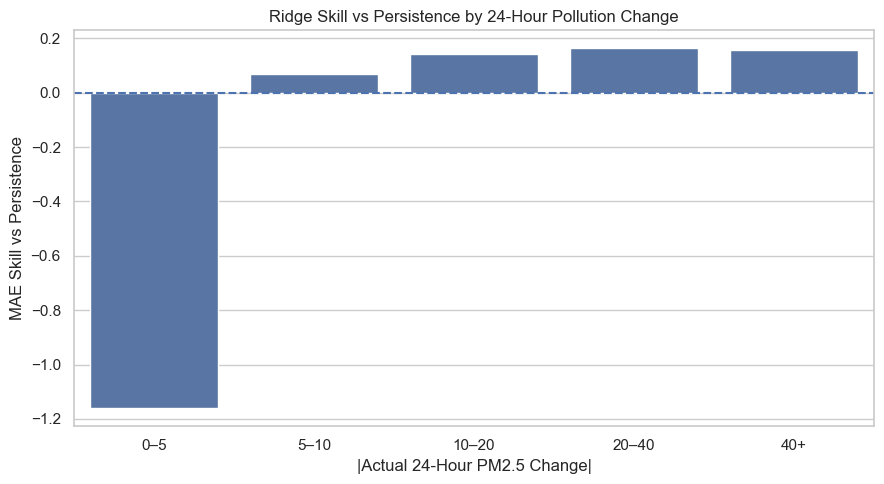

In [63]:
#Plot Ridge advantage by change magnitude
plt.figure(
    figsize=(9, 5)
)

sns.barplot(
    x=
        change_error.index,

    y=
        change_error[
            'MAE_Skill'
        ]
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title(
    'Ridge Skill vs Persistence by 24-Hour Pollution Change'
)

plt.xlabel(
    '|Actual 24-Hour PM2.5 Change|'
)

plt.ylabel(
    'MAE Skill vs Persistence'
)

plt.tight_layout()
plt.show()

## Calibration / smoothing

In [64]:
#predicted values declines
error_df[
    'prediction_decile'
] = pd.qcut(
    error_df[
        'ridge'
    ],
    q=10,
    duplicates='drop'
)

In [65]:
calibration_table = (
    error_df
    .groupby(
        'prediction_decile',
        observed=False
    )
    .agg(
        predicted_mean=(
            'ridge',
            'mean'
        ),

        actual_mean=(
            'actual',
            'mean'
        ),

        count=(
            'actual',
            'size'
        )
    )
)

In [66]:
calibration_table.round(2)

,predicted_mean,actual_mean,count
prediction_decile,,,
"(8.13, 24.861]",21.05,22.46,345
"(24.861, 31.007]",28.18,28.37,345
"(31.007, 37.286]",34.11,34.83,345
"(37.286, 44.115]",40.64,41.71,345
"(44.115, 52.042]",48.01,47.88,345
"(52.042, 63.637]",57.25,57.92,345
"(63.637, 76.761]",69.73,72.23,345
"(76.761, 87.986]",82.68,85.74,345
"(87.986, 99.474]",93.80,93.87,345


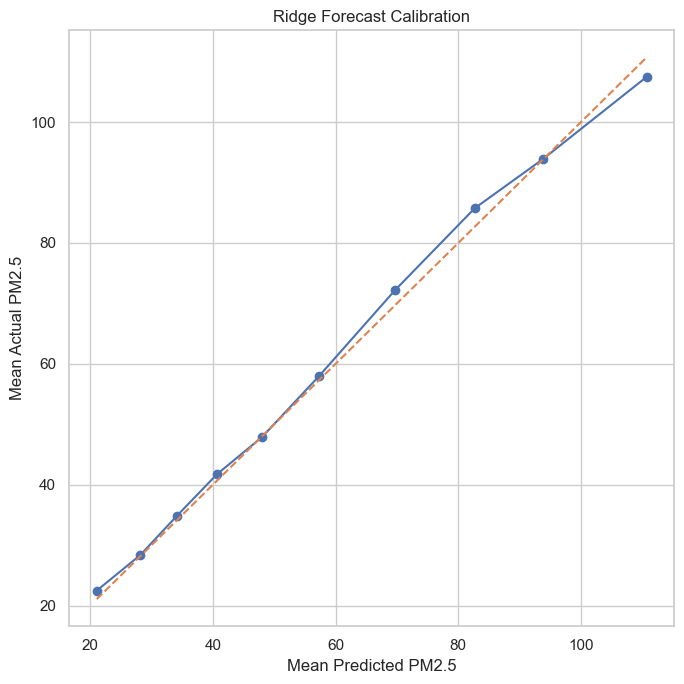

In [67]:
#Calibration plot
plt.figure(
    figsize=(7, 7)
)

plt.plot(
    calibration_table[
        'predicted_mean'
    ],

    calibration_table[
        'actual_mean'
    ],

    marker='o'
)

low = min(
    calibration_table[
        [
            'predicted_mean',
            'actual_mean'
        ]
    ]
    .min()
)

high = max(
    calibration_table[
        [
            'predicted_mean',
            'actual_mean'
        ]
    ]
    .max()
)

plt.plot(
    [low, high],
    [low, high],
    linestyle='--'
)

plt.xlabel(
    'Mean Predicted PM2.5'
)

plt.ylabel(
    'Mean Actual PM2.5'
)

plt.title(
    'Ridge Forecast Calibration'
)

plt.tight_layout()
plt.show()

## Residual diagnostics


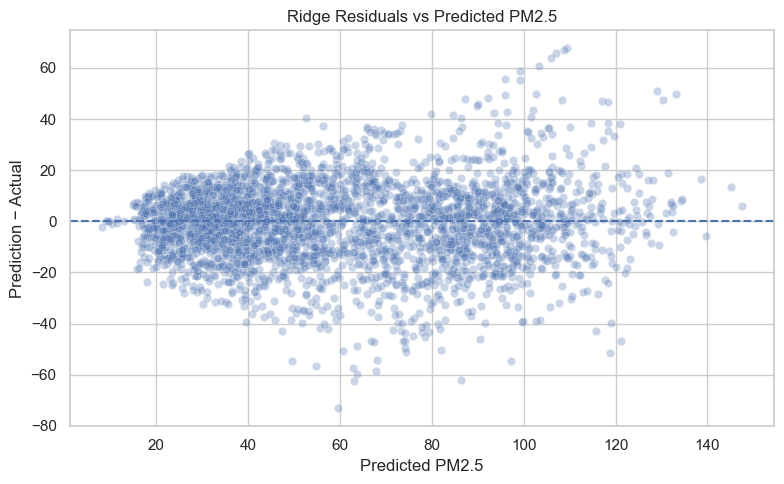

In [68]:
#Error vs prediction
plt.figure(
    figsize=(8, 5)
)

sns.scatterplot(
    data=error_df,
    x='ridge',
    y='ridge_error',
    alpha=0.3
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title(
    'Ridge Residuals vs Predicted PM2.5'
)

plt.xlabel(
    'Predicted PM2.5'
)

plt.ylabel(
    'Prediction − Actual'
)

plt.tight_layout()
plt.show()

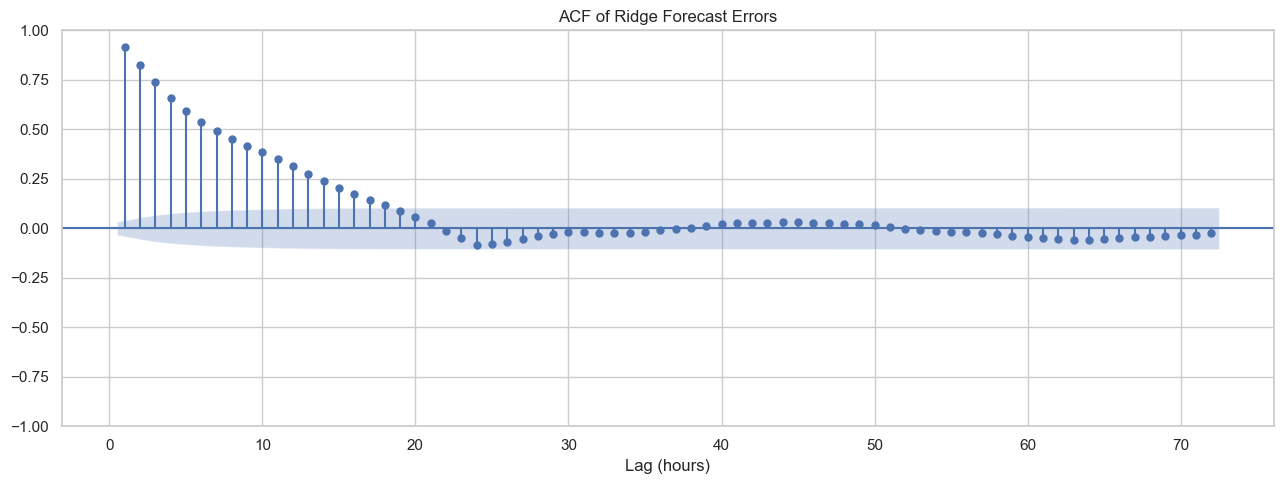

In [69]:
#Error autocorrelation
fig, ax = plt.subplots(
    figsize=(13, 5)
)

plot_acf(
    error_df[
        'ridge_error'
    ],
    lags=72,
    zero=False,
    ax=ax
)

ax.set_title(
    'ACF of Ridge Forecast Errors'
)

ax.set_xlabel(
    'Lag (hours)'
)

plt.tight_layout()
plt.show()

In [70]:
#Ljung–Box
ridge_error_ljung = (
    acorr_ljungbox(
        error_df[
            'ridge_error'
        ],

        lags=[
            1,
            6,
            12,
            24,
            48
        ],

        return_df=True
    )
)

ridge_error_ljung

,lb_stat,lb_pvalue
1,2898.199389,0.0
6,10839.698663,0.0
12,14245.006646,0.0
24,15145.682210,0.0
48,15235.167447,0.0


## Worst forecast misses

In [71]:
#Largest Ridge errors
worst_ridge_errors = (
    error_df
    .assign(
        abs_error=
            error_df[
                'ridge_abs_error'
            ]
    )
    .sort_values(
        'abs_error',
        ascending=False
    )
    .head(20)
)

worst_ridge_errors[
    [
        'target_time',
        'actual',
        'ridge',
        'persistence',
        'ridge_error',
        'persistence_error',
        'target_season',
        'target_hour'
    ]
].round(2)

/var/folders/ty/nrt7j9nn2b17y8xxtd04s2xw0000gn/T/ipykernel_81262/1316593300.py:28: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,target_time,actual,ridge,persistence,ridge_error,persistence_error,target_season,target_hour
time,,,,,,,,
2025-03-10 07:00:00,2025-03-11 07:00:00,132.7,59.57,63.6,-73.13,-69.1,Pre-Monsoon,7
2025-02-27 23:00:00,2025-02-28 23:00:00,41.8,109.42,123.9,67.62,82.1,Winter,23
2025-02-28 00:00:00,2025-03-01 00:00:00,41.7,108.85,122.5,67.15,80.8,Pre-Monsoon,0
2025-02-27 22:00:00,2025-02-28 22:00:00,41.3,107.04,120.6,65.74,79.3,Winter,22
2025-02-28 01:00:00,2025-03-01 01:00:00,42.1,106.00,119.2,63.90,77.1,Pre-Monsoon,1
2025-02-27 07:00:00,2025-02-28 07:00:00,125.3,63.01,64.0,-62.29,-61.3,Winter,7
2025-01-29 08:00:00,2025-01-30 08:00:00,148.5,86.35,92.0,-62.15,-56.5,Winter,8
2025-02-28 02:00:00,2025-03-01 02:00:00,42.4,103.29,116.2,60.89,73.8,Pre-Monsoon,2
2025-02-27 06:00:00,2025-02-28 06:00:00,123.4,63.74,66.4,-59.66,-57.0,Winter,6


In [72]:
#Largest underpredictions
worst_underpredictions = (
    error_df
    .sort_values(
        'ridge_error'
    )
    .head(20)
)

worst_underpredictions[
    [
        'target_time',
        'actual',
        'ridge',
        'persistence',
        'ridge_error',
        'target_season',
        'target_hour'
    ]
].round(2)

/var/folders/ty/nrt7j9nn2b17y8xxtd04s2xw0000gn/T/ipykernel_81262/3809895373.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,target_time,actual,ridge,persistence,ridge_error,target_season,target_hour
time,,,,,,,
2025-03-10 07:00:00,2025-03-11 07:00:00,132.7,59.57,63.6,-73.13,Pre-Monsoon,7
2025-02-27 07:00:00,2025-02-28 07:00:00,125.3,63.01,64.0,-62.29,Winter,7
2025-01-29 08:00:00,2025-01-30 08:00:00,148.5,86.35,92.0,-62.15,Winter,8
2025-02-27 06:00:00,2025-02-28 06:00:00,123.4,63.74,66.4,-59.66,Winter,6
2025-03-10 06:00:00,2025-03-11 06:00:00,126.2,67.78,71.9,-58.42,Pre-Monsoon,6
2025-02-27 05:00:00,2025-02-28 05:00:00,120.1,62.87,66.1,-57.23,Winter,5
2025-01-07 07:00:00,2025-01-08 07:00:00,111.5,54.80,43.9,-56.70,Winter,7
2025-01-07 06:00:00,2025-01-08 06:00:00,104.3,49.61,37.7,-54.69,Winter,6
2024-12-28 08:00:00,2024-12-29 08:00:00,151.8,97.21,99.7,-54.59,Winter,8


In [73]:
#outputs 
#tables
ridge_coefficients.to_csv(
    TABLES_DIR /
    "ridge_standardized_coefficients.csv",
    index=False
)

permutation_table.to_csv(
    TABLES_DIR /
    "permutation_importance.csv",
    index=False
)

bias_summary.to_csv(
    TABLES_DIR /
    "forecast_bias_summary.csv"
)

season_error.to_csv(
    TABLES_DIR /
    "forecast_error_by_season.csv"
)

month_error.to_csv(
    TABLES_DIR /
    "forecast_error_by_month.csv"
)

hour_error.to_csv(
    TABLES_DIR /
    "forecast_error_by_hour.csv"
)

regime_error.to_csv(
    TABLES_DIR /
    "forecast_error_by_pollution_regime.csv"
)

change_error.to_csv(
    TABLES_DIR /
    "forecast_error_by_24h_change.csv"
)

extreme_detection.to_csv(
    TABLES_DIR /
    "extreme_detection_metrics.csv"
)

calibration_table.to_csv(
    TABLES_DIR /
    "ridge_calibration.csv"
)

ridge_error_ljung.to_csv(
    TABLES_DIR /
    "ridge_error_ljung_box.csv"
)

error_df.to_csv(
    TABLES_DIR /
    "test_error_analysis.csv"
)

In [74]:
print("=" * 80)

print(
    "PHASE 10 — EXPLAINABILITY & "
    "FORECAST ERROR ANALYSIS"
)

print("=" * 80)


print(
    "\nOVERALL TEST PERFORMANCE"
)

print(
    pd.DataFrame({
        'Ridge':
            ridge_metrics,

        'Persistence':
            persistence_metrics
    }).round(3)
)


print(
    "\nFORECAST BIAS"
)

print(
    bias_summary.round(3)
)


print(
    "\nRIDGE WIN RATE"
)

print(
    f"{ridge_win_rate * 100:.1f}%"
)


print(
    "\nHAC ABSOLUTE-LOSS COMPARISON"
)

print(
    mae_difference_test.round(4)
)


print(
    "\nTOP 15 RIDGE COEFFICIENTS"
)

print(
    ridge_coefficients[
        [
            'feature',
            'coefficient',
            'abs_coefficient'
        ]
    ]
    .head(15)
    .round(4)
)


print(
    "\nTOP 15 PERMUTATION FEATURES"
)

print(
    permutation_table
    .head(15)
    .round(4)
)


print(
    "\nERROR BY TARGET SEASON"
)

print(
    season_error.round(3)
)


print(
    "\nERROR BY POLLUTION REGIME"
)

print(
    regime_error.round(3)
)


print(
    "\nERROR BY 24-HOUR CHANGE"
)

print(
    change_error.round(3)
)


print(
    "\nEXTREME DETECTION"
)

print(
    extreme_detection.round(3)
)


print(
    "\nEXTREME-POLLUTION BIAS"
)

print(
    extreme_bias_summary.round(3)
)


print(
    "\nRIDGE ERROR AUTOCORRELATION"
)

print(
    ridge_error_ljung
)


print("\n" + "=" * 80)

PHASE 10 — EXPLAINABILITY & FORECAST ERROR ANALYSIS

OVERALL TEST PERFORMANCE
       Ridge  Persistence
MAE   11.314       12.085
RMSE  15.028       16.284
R2     0.777        0.738

FORECAST BIAS
                      Ridge  Persistence
Mean Error           -0.634        0.300
Median Error          0.220       -0.500
Underprediction Rate  0.491        0.516
Overprediction Rate   0.509        0.480

RIDGE WIN RATE
55.4%

HAC ABSOLUTE-LOSS COMPARISON
mean_loss_improvement    0.7710
hac_standard_error       0.3164
t_statistic              2.4368
p_value                  0.0148
ci_lower                 0.1509
ci_upper                 1.3912
dtype: float64

TOP 15 RIDGE COEFFICIENTS
              feature  coefficient  abs_coefficient
0                pm25       3.9540           3.9540
35        pm10_lag_24       3.9453           3.9453
13         pm25_lag_1       3.8564           3.8564
27  pm25_roll_mean_72      -2.8617           2.8617
28   pm25_roll_std_72       2.6295           2.6295


In [75]:
print(
    ridge_coefficients[
        [
            'feature',
            'coefficient'
        ]
    ]
    .head(20)
)

print(
    permutation_table
    .head(20)
    .round(4)
)

print(
    bias_summary.round(3)
)

print(
    "Ridge win rate:",
    ridge_win_rate
)

print(
    mae_difference_test.round(4)
)

print(
    season_error.round(3)
)

print(
    regime_error.round(3)
)

print(
    change_error.round(3)
)

print(
    extreme_detection.round(3)
)

print(
    extreme_bias_summary.round(3)
)

print(
    ridge_error_ljung
)

print(
    worst_underpredictions[
        [
            'target_time',
            'actual',
            'ridge',
            'persistence',
            'ridge_error'
        ]
    ]
    .head(10)
)

                 feature  coefficient
0                   pm25     3.954037
35           pm10_lag_24     3.945268
13            pm25_lag_1     3.856402
27     pm25_roll_mean_72    -2.861701
28      pm25_roll_std_72     2.629514
3                    so2     2.570993
33       pm25_change_24h     2.559694
17           pm25_lag_24     2.495987
34            pm10_lag_1    -2.368310
1                   pm10    -2.366137
32        pm25_change_6h     2.359791
15            pm25_lag_6     2.249053
19           pm25_lag_72     2.109742
39            so2_lag_24    -2.013601
20          pm25_lag_168     1.399936
42  temperature_mean_24h    -1.327276
53        target_doy_sin    -1.326818
21      pm25_roll_mean_6     1.307432
43     humidity_mean_24h    -1.294712
4                     co     1.235057
               feature  importance_mean  importance_std
32      pm25_change_6h           2.7583          0.0927
0                 pm25           2.6556          0.0744
13          pm25_lag_1           2

In [76]:
hac_sensitivity = []

for maxlags in [24, 48, 72, 168]:

    model = sm.OLS(
        mae_loss_difference.values,
        np.ones(len(mae_loss_difference))
    ).fit(
        cov_type='HAC',
        cov_kwds={
            'maxlags': maxlags
        }
    )

    hac_sensitivity.append({
        'maxlags': maxlags,
        'mean_improvement': model.params[0],
        'std_error': model.bse[0],
        't_statistic': model.tvalues[0],
        'p_value': model.pvalues[0],
        'ci_lower': model.conf_int()[0, 0],
        'ci_upper': model.conf_int()[0, 1]
    })

hac_sensitivity = pd.DataFrame(
    hac_sensitivity
)

hac_sensitivity.round(4)

,maxlags,mean_improvement,std_error,t_statistic,p_value,ci_lower,ci_upper
0,24,0.771,0.3164,2.4368,0.0148,0.1509,1.3912
1,48,0.771,0.3302,2.3349,0.0195,0.1238,1.4183
2,72,0.771,0.3183,2.4223,0.0154,0.1472,1.3949
3,168,0.771,0.3130,2.4635,0.0138,0.1576,1.3845


## Phase 10 Summary: Explainability and Forecast Error Analysis

Post-hoc explainability and error analysis clarified why the Ridge model
provided a modest forecasting improvement over the 24-hour persistence
baseline during the held-out high-pollution test period.

Recent pollution dynamics dominated the Ridge forecast. Current PM2.5,
one-hour and 24-hour PM2.5 history, recent PM2.5 changes, PM10 history,
and medium-term rolling pollution statistics were among the strongest
predictive variables. Permutation importance identified the six-hour
PM2.5 change as the single most influential feature, followed by current
PM2.5 and one-hour lagged PM2.5. This finding is consistent with the
strong temporal persistence identified in the earlier time-series
analysis.

Ridge achieved lower absolute error than persistence for approximately
55.4% of test forecasts. The mean reduction in absolute error was
approximately 0.77 PM2.5 units. A HAC/Newey-West comparison of the
forecast loss differential indicated statistical evidence of lower
average absolute error for Ridge under the primary 24-hour covariance
window.

The source of Ridge's advantage depended strongly on pollution dynamics.
When PM2.5 changed by less than five units over 24 hours, persistence was
substantially more accurate than Ridge. Once the 24-hour change exceeded
five units, Ridge became more accurate, with its relative MAE improvement
increasing to approximately 14–16% for changes greater than ten units.
Thus, the principal value of the multivariable model was its ability to
adapt to changing conditions rather than reproduce highly stable
day-to-day pollution.

The model's advantage also depended on pollution regime and season.
Persistence remained more accurate under low or typical pollution,
whereas Ridge outperformed persistence under elevated, high, very-high,
and extreme concentration regimes. Within the held-out test period,
Ridge reduced winter MAE by approximately 10.5% relative to persistence,
while its overall advantage during the pre-monsoon portion was minimal.

Despite improved overall high-pollution MAE, Ridge demonstrated systematic
regression toward the mean. Low concentrations tended to be
overpredicted, while very high and extreme concentrations were
underpredicted. Among development-defined high-pollution observations,
Ridge exhibited greater negative bias than persistence, and its
high-pollution recall was slightly lower, although its precision was
slightly higher and both methods produced similar F1 scores. Consequently,
improvement in continuous regression accuracy did not translate into a
clear improvement in high-pollution event detection.

Overall forecast bias was small and calibration across predicted-value
deciles was reasonably strong, but several large errors occurred during
abrupt pollution increases and decreases. Forecast residuals also
exhibited substantial serial autocorrelation through multiple temporal
lags, demonstrating that exploitable temporal structure remains after
the Ridge forecast.

These findings indicate that the Ridge model offers modest incremental
forecasting value beyond strong daily persistence, particularly during
changing and high-pollution conditions. However, peak underprediction,
remaining temporal residual structure, and limited improvement in
high-pollution detection remain important limitations.